# 04 — Continuous-time models: Latent ODE and Neural CDE

This notebook adds the two continuous-time architectures already implemented in `src/models/`:

- **Latent ODE** — Rubanova, Chen & Duvenaud (2019)
- **Neural CDE** — Kidger, Morrill, Foster & Lyons (2020)

The experimental protocol is deliberately the same as Notebook 03:

1. use only **Set A outcomes** for development;
2. split A into 80% development-train / 20% development-validation with `SEED=42`;
3. fit the development normalizer on A-development-train only;
4. select training duration and the Event-1 threshold on A-development-validation;
5. freeze all choices;
6. refit preprocessing on all A and retrain each final model for the selected number of epochs;
7. only then load B and C, generate and freeze their predictions;
8. only after predictions are frozen, read `Outcomes-b.txt` / `Outcomes-c.txt` for retrospective scoring.

The models use the project's current **hourly 0–48 h representation**. Therefore this notebook evaluates continuous-time latent dynamics on a common discretised observation grid; it does **not** yet claim a fully raw-timestamp experiment.

In [1]:
import sys, copy, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Start Jupyter from repository root or notebooks/.")

sys.path.insert(0, str(PROJECT_ROOT))

from src.data.physionet import load_split
from src.data.preprocessing import Physionet2012Dataset, build_vocab, fill_forward
from src.models.latent_ode import LatentODE, kl_standard_normal, masked_mse
from src.models.neural_cde import NeuralCDE

RAW_DIR = PROJECT_ROOT / "data" / "raw"
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 110
print("Project root:", PROJECT_ROOT)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

Project root: C:\Users\guido\git_projects\icu-continuous-forecasting
PyTorch: 2.14.0+cpu
Device: cpu


## 1. Development data: Set A only

At this stage neither B nor C is loaded. This keeps model selection completely inside Set A.

In [2]:
A = load_split(RAW_DIR, split="set-a")
assert len(A) == 4000
assert all(r.label is not None for r in A)

yA = np.asarray([int(r.label) for r in A], dtype=np.int64)
idx = np.arange(len(A))
tr_idx, va_idx = train_test_split(
    idx, test_size=0.20, random_state=SEED, stratify=yA
)
A_tr = [A[i] for i in tr_idx]
A_va = [A[i] for i in va_idx]

dev_vocab = build_vocab(A_tr)
dev_tr_ds = Physionet2012Dataset(A_tr, dev_vocab)
dev_norm = dev_tr_ds.fit_normalizer()

# Reuse the fitted training normalizer explicitly; do not refit on validation.
dev_va_ds = Physionet2012Dataset(A_va, dev_vocab, normalizer=dev_norm)

print("A development train:", len(dev_tr_ds))
print("A development validation:", len(dev_va_ds))
print("Vocabulary:", len(dev_vocab))
print("Train mortality:", np.mean([r.label for r in A_tr]).round(4))
print("Validation mortality:", np.mean([r.label for r in A_va]).round(4))

A development train: 3200
A development validation: 800
Vocabulary: 36
Train mortality: 0.1384
Validation mortality: 0.1388


## 2. Official/modern metrics

As in Notebook 03, Event 1's threshold is selected on A-validation and then frozen. B/C are never used to select it.

Event 2 is retained exactly as used in Notebook 03 so that all five models are compared under the same implementation. The unusually large Event-2 values seen for some baselines in Notebook 03 should be interpreted as a calibration diagnostic and investigated separately rather than used for model tuning on C.

In [3]:
def event1(y, pred):
    y = np.asarray(y, int)
    pred = np.asarray(pred, int)
    tp = np.sum((pred == 1) & (y == 1))
    fp = np.sum((pred == 1) & (y == 0))
    fn = np.sum((pred == 0) & (y == 1))
    se = tp / (tp + fn) if tp + fn else 0.0
    ppv = tp / (tp + fp) if tp + fp else 0.0
    return min(se, ppv), se, ppv

def choose_threshold(y, risk):
    cand = np.unique(np.r_[0.0, risk, 1.0])
    scored = [(event1(y, risk >= t)[0], -abs(t - 0.5), float(t)) for t in cand]
    return max(scored)[2]

def event2(y, risk):
    y = np.asarray(y, float)
    risk = np.asarray(risk, float)
    order = np.argsort(risk, kind="mergesort")
    groups = np.array_split(order, 10)
    H = 0.0
    pis = []
    for ids in groups:
        N = len(ids)
        O = y[ids].sum()
        pi = risk[ids].mean()
        E = N * pi
        H += (O - E) ** 2 / (N * pi * (1 - pi) + 0.001)
        pis.append(pi)
    D = pis[-1] - pis[0]
    return np.inf if D <= 0 else H / D

def metrics(y, risk, thr):
    pred = (risk >= thr).astype(int)
    s, se, ppv = event1(y, pred)
    return {
        "AUROC": roc_auc_score(y, risk),
        "AUPRC": average_precision_score(y, risk),
        "Event1": s,
        "Sensitivity": se,
        "PPV": ppv,
        "Threshold": thr,
        "Event2": event2(y, risk),
    }

## 3. Dataset batching

Unlike Notebook 03, we keep `Batch` objects because both continuous-time model implementations consume `batch.times`, masks, static covariates and delta-times directly.

For Latent ODE the encoder additionally receives forward-filled, normalized values. Neural CDE builds its interpolation directly from `batch.values` and `batch.mask`.

In [4]:
BATCH = 128
MAX_EPOCHS = 30
PATIENCE = 6
LR = 1e-3
GRAD_CLIP = 5.0

# Latent ODE objective weights.
RECON_WEIGHT = 0.1
KL_WEIGHT = 1e-3

def iter_batches(ds, batch_size=BATCH, shuffle=False):
    ids = np.arange(len(ds))
    if shuffle:
        np.random.shuffle(ids)
    for s in range(0, len(ids), batch_size):
        yield ds.collate(ids[s:s + batch_size].tolist()).to(DEVICE)

def filled_from_batch(batch):
    # fill_forward is NumPy-based and uses 0 == training mean after normalization.
    x = batch.values.detach().cpu().numpy()
    m = batch.mask.detach().cpu().numpy()
    ff = fill_forward(x, m).astype("float32")
    return torch.from_numpy(ff).to(batch.values.device)

def labels_numpy(ds):
    return np.asarray(
        [np.nan if r.label is None else float(r.label) for r in ds.records],
        dtype=np.float32,
    )

## 4. Training utilities

Model selection follows Notebook 03: validation **AUPRC** determines the best epoch, with patience 6. The Event-1 threshold is selected only after restoring the best validation checkpoint.

For Latent ODE, the training loss is:

\[
L = L_{BCE} + 0.1 L_{reconstruction} + 10^{-3} L_{KL}.
\]

Validation predictions are deterministic (`sample=False`), while stochastic posterior samples are used during training.

In [5]:
def forward_logits(model, batch, kind, training):
    if kind == "latent_ode":
        filled = filled_from_batch(batch)
        logits, recon, mean, logvar = model(batch, filled, sample=training)
        return logits, (recon, mean, logvar)
    if kind == "neural_cde":
        return model(batch), None
    raise ValueError(kind)

def train_one_epoch(model, ds, optimizer, kind):
    model.train()
    bce_fn = nn.BCEWithLogitsLoss()
    total = 0.0
    n = 0

    for batch in iter_batches(ds, shuffle=True):
        optimizer.zero_grad(set_to_none=True)
        logits, aux = forward_logits(model, batch, kind, training=True)
        y = batch.labels.float()
        bce = bce_fn(logits, y)
        loss = bce

        if kind == "latent_ode":
            recon, mean, logvar = aux
            rec = masked_mse(recon, batch.values, batch.mask).mean()
            kl = kl_standard_normal(mean, logvar).mean()
            loss = bce + RECON_WEIGHT * rec + KL_WEIGHT * kl

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        bs = len(y)
        total += float(loss.detach()) * bs
        n += bs

    return total / n

@torch.no_grad()
def predict(model, ds, kind):
    model.eval()
    risks = []
    for batch in iter_batches(ds, shuffle=False):
        logits, _ = forward_logits(model, batch, kind, training=False)
        risks.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(risks)

def develop(model, kind):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    best_ap = -np.inf
    best_epoch = None
    best_state = None
    history = []
    stale = 0
    y_val = labels_numpy(dev_va_ds)

    for epoch in range(1, MAX_EPOCHS + 1):
        t0 = time.perf_counter()
        loss = train_one_epoch(model, dev_tr_ds, opt, kind)
        val_risk = predict(model, dev_va_ds, kind)
        auc = roc_auc_score(y_val, val_risk)
        ap = average_precision_score(y_val, val_risk)
        elapsed = time.perf_counter() - t0

        history.append({
            "epoch": epoch, "loss": loss,
            "val_AUROC": auc, "val_AUPRC": ap,
            "seconds": elapsed,
        })
        print(
            f"{epoch:02d} loss={loss:.4f} "
            f"val_AUROC={auc:.4f} val_AUPRC={ap:.4f} "
            f"time={elapsed:.1f}s"
        )

        if ap > best_ap:
            best_ap = ap
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1

        if stale >= PATIENCE:
            print(f"Early stopping. Best epoch: {best_epoch}")
            break

    model.load_state_dict(best_state)
    return model, best_epoch, pd.DataFrame(history)

def train_fixed(model, ds, epochs, kind):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()
        loss = train_one_epoch(model, ds, opt, kind)
        print(f"{epoch:02d}/{epochs:02d} loss={loss:.4f} time={time.perf_counter()-t0:.1f}s")
    return model

## 5. Develop Latent ODE on Set A

The architecture is imported from `src/models/latent_ode.py`; the notebook does not redefine it.

In [6]:
D = len(dev_vocab)
S = len(dev_tr_ds.static_names)

torch.manual_seed(SEED)
latent_dev = LatentODE(
    input_dim=D,
    static_dim=S,
    latent_dim=16,
    hidden=64,
    solver="dopri5",
)
latent_dev, latent_epochs, latent_hist = develop(latent_dev, "latent_ode")

latent_val = predict(latent_dev, dev_va_ds, "latent_ode")
latent_thr = choose_threshold(labels_numpy(dev_va_ds), latent_val)

print("Latent ODE selected epochs:", latent_epochs)
print("Latent ODE Event-1 threshold:", round(latent_thr, 4))

01 loss=0.6704 val_AUROC=0.7446 val_AUPRC=0.3032 time=49.7s
02 loss=0.4912 val_AUROC=0.7821 val_AUPRC=0.3452 time=53.2s
03 loss=0.4615 val_AUROC=0.7999 val_AUPRC=0.3538 time=56.1s
04 loss=0.4442 val_AUROC=0.8232 val_AUPRC=0.3894 time=55.3s
05 loss=0.4311 val_AUROC=0.8344 val_AUPRC=0.4276 time=54.0s
06 loss=0.4206 val_AUROC=0.8362 val_AUPRC=0.4472 time=52.7s
07 loss=0.4087 val_AUROC=0.8437 val_AUPRC=0.4680 time=52.2s
08 loss=0.3962 val_AUROC=0.8509 val_AUPRC=0.4947 time=52.0s
09 loss=0.3882 val_AUROC=0.8539 val_AUPRC=0.4912 time=50.7s
10 loss=0.3765 val_AUROC=0.8630 val_AUPRC=0.5135 time=52.3s
11 loss=0.3674 val_AUROC=0.8608 val_AUPRC=0.5115 time=51.3s
12 loss=0.3562 val_AUROC=0.8543 val_AUPRC=0.4973 time=50.6s
13 loss=0.3475 val_AUROC=0.8591 val_AUPRC=0.4932 time=53.4s
14 loss=0.3380 val_AUROC=0.8564 val_AUPRC=0.5072 time=52.3s
15 loss=0.3224 val_AUROC=0.8529 val_AUPRC=0.4873 time=26.5s
16 loss=0.3069 val_AUROC=0.8378 val_AUPRC=0.4575 time=19.1s
Early stopping. Best epoch: 10
Latent OD

## 6. Develop Neural CDE on Set A

The CDE control path contains time, normalized measurements and the observation mask. The repository implementation uses Hermite cubic interpolation and an RK4 CDE solver.

In [7]:
torch.manual_seed(SEED)
cde_dev = NeuralCDE(
    input_dim=D,
    static_dim=S,
    hidden_channels=32,
    hidden=64,
    interpolation="cubic",
    solver="rk4",
    step_size=1.0,
)
cde_dev, cde_epochs, cde_hist = develop(cde_dev, "neural_cde")

cde_val = predict(cde_dev, dev_va_ds, "neural_cde")
cde_thr = choose_threshold(labels_numpy(dev_va_ds), cde_val)

selected = pd.DataFrame([
    {"Model": "Latent ODE", "epochs": latent_epochs, "Event1_threshold": latent_thr},
    {"Model": "Neural CDE", "epochs": cde_epochs, "Event1_threshold": cde_thr},
]).set_index("Model")

display(selected.round(4))

01 loss=0.4748 val_AUROC=0.6668 val_AUPRC=0.2506 time=399.5s
02 loss=0.3598 val_AUROC=0.7427 val_AUPRC=0.2884 time=402.8s
03 loss=0.3377 val_AUROC=0.7619 val_AUPRC=0.3062 time=426.7s
04 loss=0.3276 val_AUROC=0.7666 val_AUPRC=0.3113 time=399.7s
05 loss=0.3207 val_AUROC=0.7859 val_AUPRC=0.3235 time=371.0s
06 loss=0.3354 val_AUROC=0.7790 val_AUPRC=0.3112 time=367.0s
07 loss=0.3279 val_AUROC=0.7797 val_AUPRC=0.3258 time=367.7s
08 loss=0.3153 val_AUROC=0.7747 val_AUPRC=0.3299 time=366.5s
09 loss=0.2946 val_AUROC=0.7798 val_AUPRC=0.3607 time=363.8s
10 loss=0.3086 val_AUROC=0.7441 val_AUPRC=0.3130 time=375.9s
11 loss=0.3300 val_AUROC=0.7353 val_AUPRC=0.2870 time=366.7s
12 loss=0.3000 val_AUROC=0.7484 val_AUPRC=0.2852 time=366.7s
13 loss=0.2947 val_AUROC=0.7609 val_AUPRC=0.2891 time=381.3s
14 loss=0.2924 val_AUROC=0.7515 val_AUPRC=0.3199 time=451.1s
15 loss=0.2942 val_AUROC=0.7642 val_AUPRC=0.3176 time=501.9s
Early stopping. Best epoch: 9


,epochs,Event1_threshold
Model,,
Latent ODE,10,0.3061
Neural CDE,9,0.2398


## 7. Development curves

These curves are diagnostic only; all decisions remain based on A-validation.

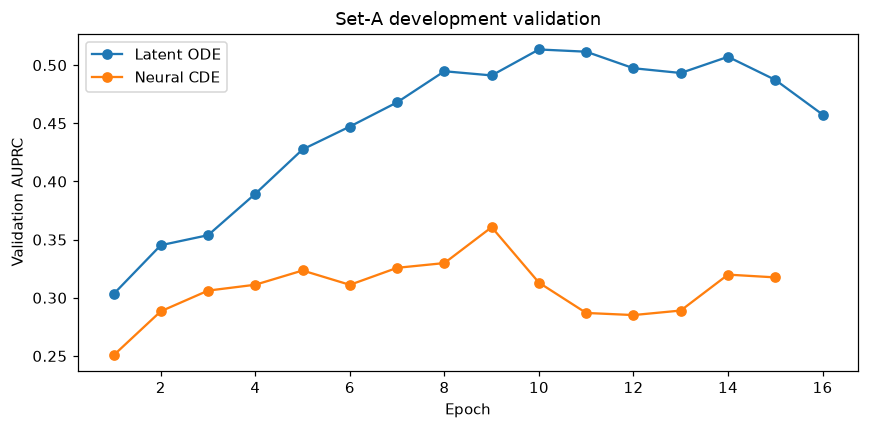

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(latent_hist["epoch"], latent_hist["val_AUPRC"], marker="o", label="Latent ODE")
plt.plot(cde_hist["epoch"], cde_hist["val_AUPRC"], marker="o", label="Neural CDE")
plt.xlabel("Epoch")
plt.ylabel("Validation AUPRC")
plt.title("Set-A development validation")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Freeze choices and refit preprocessing on all A

From this point onward, `latent_epochs`, `cde_epochs`, `latent_thr`, and `cde_thr` are frozen.

The normalizer is refitted on **all of Set A**, which is appropriate after model selection has finished.

In [9]:
final_vocab = build_vocab(A)
assert final_vocab == build_vocab(A), "Vocabulary construction must be deterministic."

A_ds = Physionet2012Dataset(A, final_vocab)
final_norm = A_ds.fit_normalizer()

D_final = len(final_vocab)
S_final = len(A_ds.static_names)

print("Final A vocabulary:", D_final)
print("All-A patients:", len(A_ds))

Final A vocabulary: 36
All-A patients: 4000


## 9. Retrain final continuous-time models on all A

The final models are trained from scratch for the epoch counts selected on A-validation.

In [10]:
torch.manual_seed(SEED)
latent_final = LatentODE(
    input_dim=D_final,
    static_dim=S_final,
    latent_dim=16,
    hidden=64,
    solver="dopri5",
)
latent_final = train_fixed(latent_final, A_ds, latent_epochs, "latent_ode")

torch.manual_seed(SEED)
cde_final = NeuralCDE(
    input_dim=D_final,
    static_dim=S_final,
    hidden_channels=32,
    hidden=64,
    interpolation="cubic",
    solver="rk4",
    step_size=1.0,
)
cde_final = train_fixed(cde_final, A_ds, cde_epochs, "neural_cde")

01/10 loss=0.6329 time=21.5s
02/10 loss=0.4785 time=24.5s
03/10 loss=0.4504 time=23.8s
04/10 loss=0.4332 time=24.0s
05/10 loss=0.4188 time=24.2s
06/10 loss=0.4060 time=24.7s
07/10 loss=0.3927 time=24.4s
08/10 loss=0.3814 time=23.3s
09/10 loss=0.3749 time=23.4s
10/10 loss=0.3615 time=25.5s
01/09 loss=0.4744 time=415.2s
02/09 loss=0.3669 time=421.6s
03/09 loss=0.3362 time=416.7s
04/09 loss=0.3279 time=400.7s
05/09 loss=0.3411 time=415.3s
06/09 loss=0.3238 time=402.2s
07/09 loss=0.3309 time=399.0s
08/09 loss=0.3141 time=399.1s
09/09 loss=0.3069 time=415.6s


## 10. Load B/C only after model choices are frozen

B and C are loaded without outcomes. Their records are transformed with the normalizer fitted on all A.

This requires the corrected `Physionet2012Dataset` used by the current repository, which retains unlabeled records.

In [11]:
B = load_split(RAW_DIR, split="set-b")
C = load_split(RAW_DIR, split="set-c")

assert len(B) == len(C) == 4000
assert all(r.label is None for r in B), "B unexpectedly has labels attached."
assert all(r.label is None for r in C), "C unexpectedly has labels attached."

unseen_B = sorted(set(build_vocab(B)) - set(final_vocab))
unseen_C = sorted(set(build_vocab(C)) - set(final_vocab))
assert not unseen_B, f"B variables absent from A vocabulary: {unseen_B}"
assert not unseen_C, f"C variables absent from A vocabulary: {unseen_C}"

B_ds = Physionet2012Dataset(B, final_vocab, normalizer=final_norm)
C_ds = Physionet2012Dataset(C, final_vocab, normalizer=final_norm)

assert len(B_ds) == len(C_ds) == 4000
print("B/C loaded unlabeled and transformed with frozen A preprocessing.")

B/C loaded unlabeled and transformed with frozen A preprocessing.


## 11. Freeze B/C predictions before reading outcomes

The next cell is the competition-style prediction boundary. After it runs, no model parameter, epoch count, threshold, preprocessing choice or architecture may be changed based on B/C outcomes.

In [12]:
risk_B = {
    "Latent ODE": predict(latent_final, B_ds, "latent_ode"),
    "Neural CDE": predict(cde_final, B_ds, "neural_cde"),
}
risk_C = {
    "Latent ODE": predict(latent_final, C_ds, "latent_ode"),
    "Neural CDE": predict(cde_final, C_ds, "neural_cde"),
}
thr = {
    "Latent ODE": latent_thr,
    "Neural CDE": cde_thr,
}

def submission(records, risk, threshold):
    return pd.DataFrame({
        "RecordID": [str(r.record_id) for r in records],
        "Prediction": (risk >= threshold).astype(int),
        "Risk": risk,
    })

submissions_B = {m: submission(B, r, thr[m]) for m, r in risk_B.items()}
submissions_C = {m: submission(C, r, thr[m]) for m, r in risk_C.items()}

for split_name, submissions in [("B", submissions_B), ("C", submissions_C)]:
    for model_name, df in submissions.items():
        assert len(df) == 4000
        assert df["RecordID"].is_unique
        assert np.isfinite(df["Risk"]).all()
        assert df["Risk"].between(0, 1).all()

print("PREDICTIONS FROZEN. B/C outcomes have not been read by this notebook up to this point.")
display(submissions_C["Neural CDE"].head())

PREDICTIONS FROZEN. B/C outcomes have not been read by this notebook up to this point.


,RecordID,Prediction,Risk
0,152871,1,0.558676
1,152873,1,0.527430
2,152875,0,0.087123
3,152878,0,0.010718
4,152882,0,0.083686


## 12. Retrospective scoring — information firewall ends here

Only now are the released B/C outcome files read. Record IDs are explicitly parsed as strings and checked for exact one-to-one alignment before scoring.

In [13]:
def read_outcomes(path):
    df = pd.read_csv(path, dtype={"RecordID": str})
    df["RecordID"] = df["RecordID"].str.strip()
    assert df["RecordID"].is_unique, f"Duplicate RecordID in {path.name}"
    return df.set_index("RecordID")["In-hospital_death"]

def aligned_y(records, outcome_map):
    record_ids = [str(r.record_id).strip() for r in records]
    missing = sorted(set(record_ids) - set(outcome_map.index))
    extra = sorted(set(outcome_map.index) - set(record_ids))
    assert not missing, f"Missing outcome IDs: {missing[:10]}"
    assert not extra, f"Outcome IDs without records: {extra[:10]}"
    return np.asarray([int(outcome_map.loc[rid]) for rid in record_ids], dtype=np.int64)

yB_map = read_outcomes(RAW_DIR / "Outcomes-b.txt")
yC_map = read_outcomes(RAW_DIR / "Outcomes-c.txt")
yB = aligned_y(B, yB_map)
yC = aligned_y(C, yC_map)

print("B:", len(yB), "deaths:", yB.sum())
print("C:", len(yC), "deaths:", yC.sum())

rows = []
for m in ["Latent ODE", "Neural CDE"]:
    rows.append({"Model": m, "Set": "B", **metrics(yB, risk_B[m], thr[m])})
    rows.append({"Model": m, "Set": "C", **metrics(yC, risk_C[m], thr[m])})

continuous_results = pd.DataFrame(rows)
display(continuous_results.round(4))

B: 4000 deaths: 568
C: 4000 deaths: 585


,Model,Set,AUROC,AUPRC,Event1,Sensitivity,PPV,Threshold,Event2
0,Latent ODE,B,0.8489,0.4850,0.4619,0.5757,0.4619,0.3061,34.5598
1,Latent ODE,C,0.8460,0.4960,0.4772,0.5538,0.4772,0.3061,40.1119
2,Neural CDE,B,0.7538,0.3162,0.3187,0.5106,0.3187,0.2398,118.5846
3,Neural CDE,C,0.7475,0.3319,0.3173,0.4838,0.3173,0.2398,217.6957


## 13. Compare with the Notebook 03 baselines

The baseline values below are copied from the **saved outputs of the executed Notebook 03** supplied for this experiment. They are not recomputed here.

Notebook 03 selected:
- GRU: 13 epochs, threshold 0.3791
- GRU-D: 13 epochs, threshold 0.3127
- Persistence threshold: 0.7609

The table below combines those frozen results with the two continuous-time models produced above.

In [14]:
baseline_results = pd.DataFrame([
    {"Model":"Persistence","Set":"B","AUROC":0.8515,"AUPRC":0.5155,"Event1":0.4966,"Sensitivity":0.5088,"PPV":0.4966,"Threshold":0.7609,"Event2":1978.1065},
    {"Model":"Persistence","Set":"C","AUROC":0.8518,"AUPRC":0.5054,"Event1":0.4769,"Sensitivity":0.4769,"PPV":0.4947,"Threshold":0.7609,"Event2":1964.5257},
    {"Model":"GRU","Set":"B","AUROC":0.8512,"AUPRC":0.5147,"Event1":0.5180,"Sensitivity":0.5317,"PPV":0.5180,"Threshold":0.3791,"Event2":53.9951},
    {"Model":"GRU","Set":"C","AUROC":0.8457,"AUPRC":0.5165,"Event1":0.4974,"Sensitivity":0.4974,"PPV":0.5052,"Threshold":0.3791,"Event2":37.0932},
    {"Model":"GRU-D","Set":"B","AUROC":0.8374,"AUPRC":0.4875,"Event1":0.4613,"Sensitivity":0.5141,"PPV":0.4613,"Threshold":0.3127,"Event2":472.6651},
    {"Model":"GRU-D","Set":"C","AUROC":0.8391,"AUPRC":0.5048,"Event1":0.4817,"Sensitivity":0.5385,"PPV":0.4817,"Threshold":0.3127,"Event2":377.8176},
])

all_results = pd.concat([baseline_results, continuous_results], ignore_index=True)
display(
    all_results.sort_values(["Set", "Model"])
               .reset_index(drop=True)
               .round(4)
)

,Model,Set,AUROC,AUPRC,Event1,Sensitivity,PPV,Threshold,Event2
0,GRU,B,0.8512,0.5147,0.5180,0.5317,0.5180,0.3791,53.9951
1,GRU-D,B,0.8374,0.4875,0.4613,0.5141,0.4613,0.3127,472.6651
2,Latent ODE,B,0.8489,0.4850,0.4619,0.5757,0.4619,0.3061,34.5598
3,Neural CDE,B,0.7538,0.3162,0.3187,0.5106,0.3187,0.2398,118.5846
4,Persistence,B,0.8515,0.5155,0.4966,0.5088,0.4966,0.7609,1978.1065
5,GRU,C,0.8457,0.5165,0.4974,0.4974,0.5052,0.3791,37.0932
6,GRU-D,C,0.8391,0.5048,0.4817,0.5385,0.4817,0.3127,377.8176
7,Latent ODE,C,0.8460,0.4960,0.4772,0.5538,0.4772,0.3061,40.1119
8,Neural CDE,C,0.7475,0.3319,0.3173,0.4838,0.3173,0.2398,217.6957
9,Persistence,C,0.8518,0.5054,0.4769,0.4769,0.4947,0.7609,1964.5257


## 14. Final Set-C comparison

Set C is the historical final-test set. We display the five models side by side without using C to alter any model choice.

,Model,AUROC,AUPRC,Event1,Sensitivity,PPV,Threshold,Event2
0,Persistence,0.8518,0.5054,0.4769,0.4769,0.4947,0.7609,1964.5257
1,GRU,0.8457,0.5165,0.4974,0.4974,0.5052,0.3791,37.0932
2,GRU-D,0.8391,0.5048,0.4817,0.5385,0.4817,0.3127,377.8176
3,Latent ODE,0.8460,0.4960,0.4772,0.5538,0.4772,0.3061,40.1119
4,Neural CDE,0.7475,0.3319,0.3173,0.4838,0.3173,0.2398,217.6957


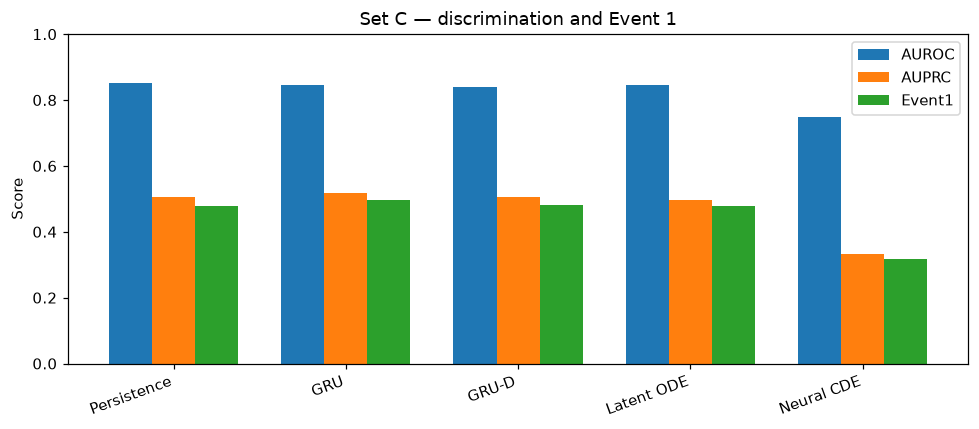

In [15]:
c_results = (
    all_results[all_results["Set"] == "C"]
    [["Model","AUROC","AUPRC","Event1","Sensitivity","PPV","Threshold","Event2"]]
    .reset_index(drop=True)
)
display(c_results.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(c_results))
w = 0.25
ax.bar(x - w, c_results["AUROC"], width=w, label="AUROC")
ax.bar(x, c_results["AUPRC"], width=w, label="AUPRC")
ax.bar(x + w, c_results["Event1"], width=w, label="Event1")
ax.set_xticks(x)
ax.set_xticklabels(c_results["Model"], rotation=20, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Set C — discrimination and Event 1")
ax.legend()
plt.tight_layout()
plt.show()

## 15. Conclusions

Notebook 04 extends the competition-faithful evaluation of Notebook 03 to two
continuous-time architectures: **Latent ODE** and **Neural CDE**.

### Experimental integrity

The full experiment completed successfully while preserving the intended
information boundary:

- model development and early stopping used only an internal split of Set A;
- preprocessing statistics were estimated without using B/C outcomes;
- epoch counts and Event-1 thresholds were selected on A-validation;
- final models were retrained from scratch on all of Set A;
- B and C were processed as unlabeled cohorts;
- predictions for B/C were frozen before their outcome files were read;
- B/C outcomes were used only for retrospective scoring.

The final Set-C cohort contained 4,000 patients, including 585 in-hospital
deaths.

### Set-C results

| Model | AUROC | AUPRC | Event 1 | Event 2 |
|---|---:|---:|---:|---:|
| Persistence | 0.8518 | 0.5054 | 0.4769 | 1964.53 |
| GRU | 0.8457 | 0.5165 | 0.4974 | 37.09 |
| GRU-D | 0.8391 | 0.5048 | 0.4817 | 377.82 |
| Latent ODE | 0.8460 | 0.4960 | 0.4772 | 40.11 |
| Neural CDE | 0.7475 | 0.3319 | 0.3173 | 217.70 |

### Interpretation

The **Latent ODE is competitive with the recurrent baselines**, but it does not
provide a consistent improvement under the current preprocessing scheme.

Its Set-C AUROC (0.8460) is essentially identical to that of the GRU (0.8457)
and higher than that of GRU-D (0.8391). However, its AUPRC (0.4960) and Event-1
score (0.4772) are lower than those of the GRU (0.5165 and 0.4974,
respectively).

The Latent ODE nevertheless obtains an Event-2 score of 40.11, close to the
GRU's 37.09 and substantially lower than the values obtained by Persistence
and GRU-D. Since Event 2 is highly sensitive to the calibration and spread of
the predicted risks, this result should be interpreted separately from
discrimination performance.

The **Neural CDE performs substantially worse in the present configuration**.
On Set C it reaches AUROC 0.7475, AUPRC 0.3319 and Event 1 0.3173. The same
performance degradation is already visible on Set B (AUROC 0.7538), suggesting
that the result is not specific to the final test cohort. Further investigation
of the CDE representation, interpolation scheme, optimization and
hyperparameters is therefore warranted before drawing conclusions about the
architecture itself.

### Main scientific conclusion

The experiment does **not** show that continuous-time modelling is inherently
superior to conventional recurrent modelling for this task.

Crucially, all models in the current study still operate on measurements
binned onto the common hourly grid `t = 0, ..., 48`. The continuous-time models
therefore model continuous hidden dynamics, but they are not yet exploiting
the original irregular observation timestamps at their full temporal
resolution.

This distinction is important: the present results compare **model
architectures while largely holding the data representation fixed**.

The Latent ODE result is encouraging because it remains competitive with the
GRU under this constraint. The next experiment should test the central
hypothesis of the project more directly by removing hourly binning and
constructing trajectories from the original irregular timestamps.

### Next step

The natural next experiment is therefore a **true irregular-time ablation**:

1. preserve the original measurement timestamps instead of hourly binning;
2. construct an appropriate continuous-time representation of observations
   and missingness;
3. train the continuous-time models on that representation;
4. retain the current hourly GRU/GRU-D results as fixed reference baselines;
5. repeat the same Set-A development → frozen Set-B/C evaluation protocol.

This will separate two questions that the current experiment cannot yet
distinguish:

> **Does the continuous-time architecture help?**

from

> **Does preserving the original irregular timing of ICU measurements help?**

Answering the second question is the key next step toward the main objective
of this project.

In [16]:
assert len(continuous_results) == 4
assert set(continuous_results["Model"]) == {"Latent ODE", "Neural CDE"}
assert set(continuous_results["Set"]) == {"B", "C"}
assert np.isfinite(continuous_results[["AUROC","AUPRC","Event1"]].to_numpy()).all()

print("Notebook 04 completed successfully.")

Notebook 04 completed successfully.
